<a href="https://colab.research.google.com/github/shankar27git/Spectral-Alignment-in-QML/blob/main/Spectral_Alignment_in_QML_final%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install yfinance

import yfinance as yf
import pandas as pd

tickers = ["AAPL", "AMZN", "GOOGL", "META", "NFLX"]

data = yf.download(tickers, start="2015-01-01", end="2024-12-31")
data.head()


/tmp/ipykernel_1648/470926208.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  5 of 5 completed


Price           Close                                                High  \
Ticker           AAPL     AMZN      GOOGL       META      NFLX       AAPL   
Date                                                                        
2015-01-02  24.214888  15.4260  26.260458  77.839165  4.984857  24.682220   
2015-01-05  23.532722  15.1095  25.760096  76.588966  4.731143  24.064285   
2015-01-06  23.534937  14.7645  25.124350  75.557076  4.650143  23.794073   
2015-01-07  23.864950  14.9210  25.050455  75.557076  4.674286  23.964618   
2015-01-08  24.781895  15.0230  25.137737  77.571259  4.778000  24.839481   

Price                                                ...       Open           \
Ticker         AMZN      GOOGL       META      NFLX  ...       AAPL     AMZN   
Date                                                 ...                       
2015-01-02  15.7375  26.570396  78.315431  5.033143  ...  24.671145  15.6290   
2015-01-05  15.4190  26.183100  78.632924  4.925857  ...  23.984551  15.3505   
2015-01-06  15.1500  25.846876  76.985858  4.764000  ...  23.596952  15.1120   
2015-01-07  15.0640  25.364856  76.757653  4.742143  ...  23.743133  14.8750   
2015-01-08  15.1570  25.166995  77.620872  4.783571  ...  24.192747  15.0160   

Price                                          Volume                      \
Ticker          GOOGL       META      NFLX       AAPL      AMZN     GOOGL   
Date                                                                        
2015-01-02  26.411706  77.968157  4.915143  212818400  55664000  26480000   
2015-01-05  26.141444  77.372816  4.925857  257142000  55484000  41182000   
2015-01-06  25.811668  76.628668  4.734714  263188400  70380000  54456000   
2015-01-07  25.338079  76.162326  4.734714  160423600  52806000  46918000   
2015-01-08  24.869950  76.142469  4.712000  237458000  61768000  73054000   

Price                            
Ticker          META       NFLX  
Date                             
2015-01-02  18177500  134750000  
2015-01-05  26452200  181650000  
2015-01-06  27399300  160377000  
2015-01-07  22045300   98497000  
2015-01-08  23961000   96019000  

[5 rows x 25 columns]

In [3]:
!pip install yfinance ta

import yfinance as yf
import pandas as pd
import numpy as np

# FAANG tickers (META instead of FB)
tickers = ["AAPL", "AMZN", "GOOGL", "META", "NFLX"]

data = yf.download(tickers, start="2015-01-01", end="2024-12-31", group_by='ticker')

data.head()


  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=3996cf6577c83afe4e4bba62b1d61955bbc0882fb1f12c394115d66a12abe1c2
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


/tmp/ipykernel_1648/2637292990.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2024-12-31", group_by='ticker')
[*********************100%***********************]  5 of 5 completed


Ticker         AMZN                                           NFLX            \
Price          Open     High      Low    Close    Volume      Open      High   
Date                                                                           
2015-01-02  15.6290  15.7375  15.3480  15.4260  55664000  4.915143  5.033143   
2015-01-05  15.3505  15.4190  15.0425  15.1095  55484000  4.925857  4.925857   
2015-01-06  15.1120  15.1500  14.6190  14.7645  70380000  4.734714  4.764000   
2015-01-07  14.8750  15.0640  14.7665  14.9210  52806000  4.734714  4.742143   
2015-01-08  15.0160  15.1570  14.8055  15.0230  61768000  4.712000  4.783571   

Ticker                                     ...       META             \
Price            Low     Close     Volume  ...       Open       High   
Date                                       ...                         
2015-01-02  4.873143  4.984857  134750000  ...  77.968157  78.315431   
2015-01-05  4.714714  4.731143  181650000  ...  77.372816  78.632924   
2015-01-06  4.566143  4.650143  160377000  ...  76.628668  76.985858   
2015-01-07  4.627143  4.674286   98497000  ...  76.162326  76.757653   
2015-01-08  4.647857  4.778000   96019000  ...  76.142469  77.620872   

Ticker                                           AAPL                        \
Price             Low      Close    Volume       Open       High        Low   
Date                                                                          
2015-01-02  77.095004  77.839165  18177500  24.671145  24.682220  23.776348   
2015-01-05  76.261534  76.588966  26452200  23.984551  24.064285  23.346676   
2015-01-06  74.773226  75.557076  27399300  23.596952  23.794073  23.173916   
2015-01-07  75.229643  75.557076  22045300  23.743133  23.964618  23.632391   
2015-01-08  75.487612  77.571259  23961000  24.192747  24.839481  24.075359   

Ticker                            
Price           Close     Volume  
Date                              
2015-01-02  24.214888  212818400  
2015-01-05  23.532722  257142000  
2015-01-06  23.534937  263188400  
2015-01-07  23.864950  160423600  
2015-01-08  24.781895  237458000  

[5 rows x 25 columns]

In [4]:
dfs = []

for ticker in tickers:
    df = data[ticker].copy()
    df["Ticker"] = ticker
    df.reset_index(inplace=True)
    dfs.append(df)

df = pd.concat(dfs)
df.head()


Price,Date,Open,High,Low,Close,Volume,Ticker
0,2015-01-02,24.671145,24.682220,23.776348,24.214888,212818400,AAPL
1,2015-01-05,23.984551,24.064285,23.346676,23.532722,257142000,AAPL
2,2015-01-06,23.596952,23.794073,23.173916,23.534937,263188400,AAPL
3,2015-01-07,23.743133,23.964618,23.632391,23.864950,160423600,AAPL
4,2015-01-08,24.192747,24.839481,24.075359,24.781895,237458000,AAPL


In [5]:
import ta

def add_indicators(df):
    df["RSI"] = ta.momentum.RSIIndicator(df["Close"]).rsi()
    df["SMA_20"] = ta.trend.SMAIndicator(df["Close"], window=20).sma_indicator()
    df["EMA_20"] = ta.trend.EMAIndicator(df["Close"], window=20).ema_indicator()

    macd = ta.trend.MACD(df["Close"])
    df["MACD"] = macd.macd()
    df["MACD_signal"] = macd.macd_signal()

    bb = ta.volatility.BollingerBands(df["Close"])
    df["BB_high"] = bb.bollinger_hband()
    df["BB_low"] = bb.bollinger_lband()

    return df

df = df.groupby("Ticker").apply(add_indicators).reset_index(drop=True)

df.head()


/tmp/ipykernel_1648/2231756062.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Ticker").apply(add_indicators).reset_index(drop=True)


Price,Date,Open,High,Low,Close,Volume,Ticker,RSI,SMA_20,EMA_20,MACD,MACD_signal,BB_high,BB_low
0,2015-01-02,24.671145,24.682220,23.776348,24.214888,212818400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,23.984551,24.064285,23.346676,23.532722,257142000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,23.596952,23.794073,23.173916,23.534937,263188400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-07,23.743133,23.964618,23.632391,23.864950,160423600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-08,24.192747,24.839481,24.075359,24.781895,237458000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
import ta

def add_indicators(df):
    df["RSI"] = ta.momentum.RSIIndicator(df["Close"]).rsi()
    df["SMA_20"] = ta.trend.SMAIndicator(df["Close"], window=20).sma_indicator()
    df["EMA_20"] = ta.trend.EMAIndicator(df["Close"], window=20).ema_indicator()

    macd = ta.trend.MACD(df["Close"])
    df["MACD"] = macd.macd()
    df["MACD_signal"] = macd.macd_signal()

    bb = ta.volatility.BollingerBands(df["Close"])
    df["BB_high"] = bb.bollinger_hband()
    df["BB_low"] = bb.bollinger_lband()

    return df

df = df.groupby("Ticker").apply(add_indicators).reset_index(drop=True)

df.head()


/tmp/ipykernel_1648/2231756062.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Ticker").apply(add_indicators).reset_index(drop=True)


Price,Date,Open,High,Low,Close,Volume,Ticker,RSI,SMA_20,EMA_20,MACD,MACD_signal,BB_high,BB_low
0,2015-01-02,24.671145,24.682220,23.776348,24.214888,212818400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,23.984551,24.064285,23.346676,23.532722,257142000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,23.596952,23.794073,23.173916,23.534937,263188400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-07,23.743133,23.964618,23.632391,23.864950,160423600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-08,24.192747,24.839481,24.075359,24.781895,237458000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df["Future_Close"] = df.groupby("Ticker")["Close"].shift(-1)
df["Target"] = (df["Future_Close"] > df["Close"]).astype(int)

df = df.dropna()

df[["Close", "Future_Close", "Target"]].head()


Price,Close,Future_Close,Target
33,28.795433,29.573683,1
34,29.573683,29.389130,0
35,29.389130,28.637556,0
36,28.637556,28.999998,1
37,28.999998,28.564178,0


In [8]:
from sklearn.model_selection import train_test_split

features = [
    "RSI", "SMA_20", "EMA_20",
    "MACD", "MACD_signal",
    "BB_high", "BB_low", "Volume"
]

X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 0.5268037081821846
              precision    recall  f1-score   support

           0       0.53      0.38      0.44      1221
           1       0.53      0.67      0.59      1260

    accuracy                           0.53      2481
   macro avg       0.53      0.52      0.52      2481
weighted avg       0.53      0.53      0.52      2481



In [10]:
from sklearn.model_selection import train_test_split

features = [
    "RSI", "SMA_20", "EMA_20",
    "MACD", "MACD_signal",
    "BB_high", "BB_low", "Volume"
]

X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 0.5268037081821846
              precision    recall  f1-score   support

           0       0.53      0.38      0.44      1221
           1       0.53      0.67      0.59      1260

    accuracy                           0.53      2481
   macro avg       0.53      0.52      0.52      2481
weighted avg       0.53      0.53      0.52      2481



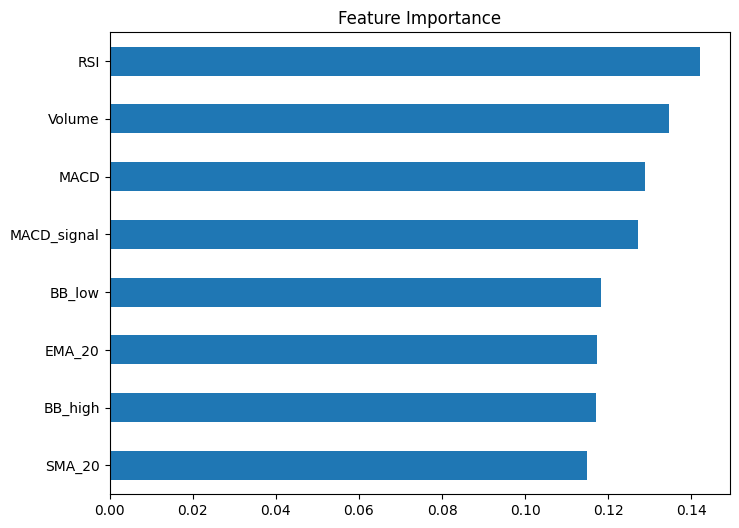

In [12]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()


In [13]:
df_test = df.iloc[-len(y_test):].copy()
df_test["Prediction"] = preds

# Strategy Return
df_test["Market_Return"] = df_test["Close"].pct_change()
df_test["Strategy_Return"] = df_test["Market_Return"] * df_test["Prediction"]

df_test.head()


Price,Date,Open,High,Low,Close,Volume,Ticker,RSI,SMA_20,EMA_20,MACD,MACD_signal,BB_high,BB_low,Future_Close,Target,Prediction,Market_Return,Strategy_Return
10093,2015-02-20,6.795000,6.837429,6.763714,6.831429,94220000,NFLX,79.919089,6.484843,6.364119,0.355085,0.361841,6.835925,6.133761,6.740571,0,0,NaN,NaN
10094,2015-02-23,6.830000,6.831429,6.714286,6.740571,90314000,NFLX,73.609596,6.509400,6.399972,0.342036,0.357880,6.859888,6.158912,6.784000,1,0,-0.013300,-0.0
10095,2015-02-24,6.737286,6.808429,6.735571,6.784000,60753000,NFLX,74.640196,6.529629,6.436546,0.331378,0.352580,6.894193,6.165064,6.833286,1,0,0.006443,0.0
10096,2015-02-25,6.780714,6.879429,6.780714,6.833286,68544000,NFLX,75.795431,6.546886,6.474331,0.323184,0.346701,6.933943,6.159828,6.900429,1,0,0.007265,0.0
10097,2015-02-26,6.862571,6.950000,6.843000,6.900429,108528000,NFLX,77.311740,6.575864,6.514911,0.318436,0.341048,6.977405,6.174323,6.784429,0,0,0.009826,0.0


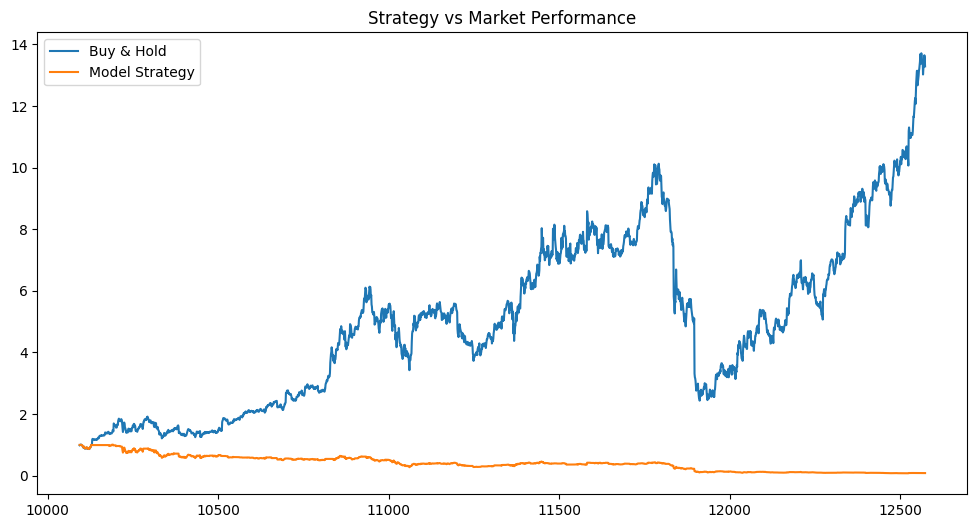

In [14]:
df_test["Cumulative_Market"] = (1 + df_test["Market_Return"]).cumprod()
df_test["Cumulative_Strategy"] = (1 + df_test["Strategy_Return"]).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_test["Cumulative_Market"], label="Buy & Hold")
plt.plot(df_test["Cumulative_Strategy"], label="Model Strategy")
plt.legend()
plt.title("Strategy vs Market Performance")
plt.show()


In [15]:
# Sharpe Ratio
sharpe = df_test["Strategy_Return"].mean() / df_test["Strategy_Return"].std()
print("Sharpe Ratio:", sharpe)

# Max Drawdown
cum_returns = df_test["Cumulative_Strategy"]
rolling_max = cum_returns.cummax()
drawdown = cum_returns / rolling_max - 1
max_drawdown = drawdown.min()

print("Max Drawdown:", max_drawdown)


Sharpe Ratio: -0.032155399591439156
Max Drawdown: -0.9226693004321345


In [16]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Use the same feature list
features = [
    "RSI", "SMA_20", "EMA_20",
    "MACD", "MACD_signal",
    "BB_high", "BB_low", "Volume"
]

X_features = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

X_scaled.shape


(12405, 8)

In [17]:
# Covariance matrix
cov_matrix = np.cov(X_scaled, rowvar=False)

cov_matrix.shape


(8, 8)

In [18]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

eigenvalues


array([ 4.45897730e+00,  2.11912197e+00,  8.55700782e-01,  5.26150628e-01,
        3.48969405e-02,  5.75092788e-03,  4.64080737e-05, -3.15394412e-16])

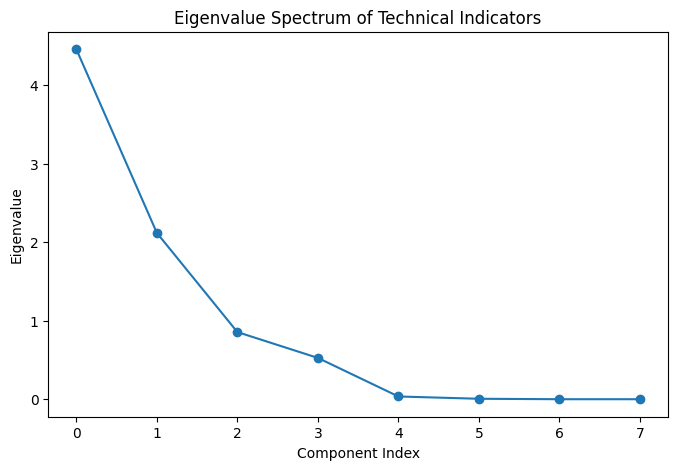

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(eigenvalues, marker='o')
plt.title("Eigenvalue Spectrum of Technical Indicators")
plt.xlabel("Component Index")
plt.ylabel("Eigenvalue")
plt.show()


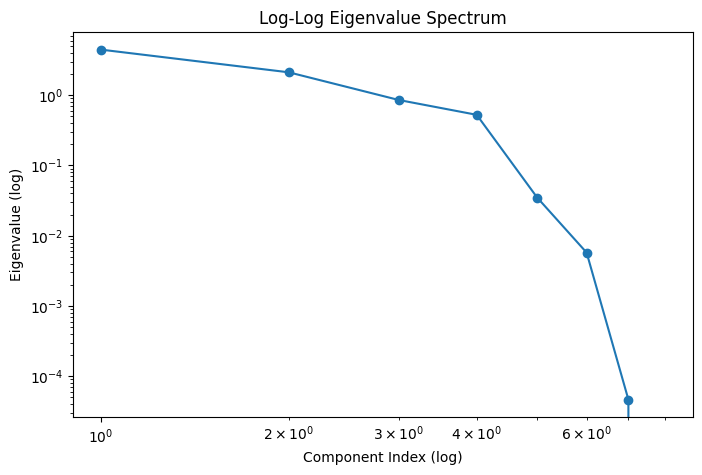

In [20]:
plt.figure(figsize=(8,5))
plt.loglog(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.title("Log-Log Eigenvalue Spectrum")
plt.xlabel("Component Index (log)")
plt.ylabel("Eigenvalue (log)")
plt.show()


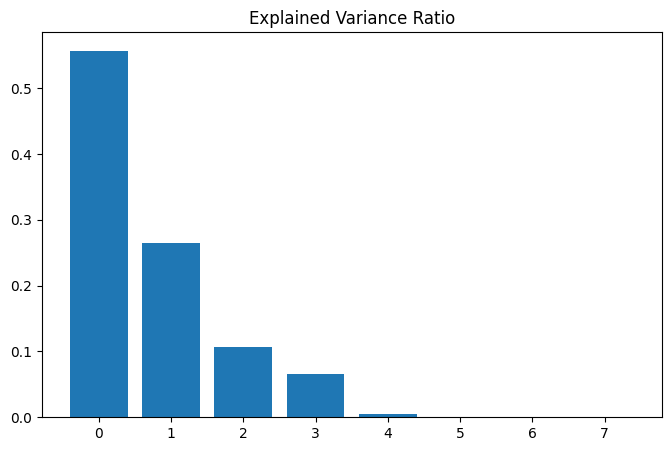

In [21]:
explained_variance_ratio = eigenvalues / eigenvalues.sum()

plt.figure(figsize=(8,5))
plt.bar(range(len(explained_variance_ratio)), explained_variance_ratio)
plt.title("Explained Variance Ratio")
plt.show()


In [22]:
cumulative_variance = np.cumsum(explained_variance_ratio)

intrinsic_dim_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Intrinsic Dimension (95% variance):", intrinsic_dim_95)


Intrinsic Dimension (95% variance): 4


In [23]:
import numpy as np

# Use your already computed eigenvalues and eigenvectors
# Make sure eigenvalues are non-negative (clip the tiny negative one)
eigenvalues_clean = np.clip(eigenvalues, 0, None)

# Number of samples to generate
n_samples = 1000

# Step 1 - Generate random Gaussian noise
Z = np.random.normal(0, 1, size=(n_samples, len(eigenvalues_clean)))

# Step 2 - Transform using eigenvectors and eigenvalues
X_syn = Z @ np.diag(np.sqrt(eigenvalues_clean)) @ eigenvectors.T

print("Synthetic Data Shape:", X_syn.shape)

# Step 3 - Verify covariance is preserved
cov_synthetic = np.cov(X_syn, rowvar=False)
cov_original = np.cov(X_scaled, rowvar=False)

print("\nOriginal Eigenvalues:", np.linalg.eigvalsh(cov_original)[::-1])
print("Synthetic Eigenvalues:", np.linalg.eigvalsh(cov_synthetic)[::-1])

Synthetic Data Shape: (1000, 8)

Original Eigenvalues: [ 4.45897730e+00  2.11912197e+00  8.55700782e-01  5.26150628e-01
  3.48969405e-02  5.75092788e-03  4.64080737e-05 -3.15394412e-16]
Synthetic Eigenvalues: [ 4.55013079e+00  2.18262883e+00  8.76042378e-01  5.38001623e-01
  3.34844206e-02  5.34677025e-03  4.65063667e-05 -3.09539721e-16]


In [24]:
# Power law decay
def power_law_eigenvalues(d, alpha, total_variance):
    raw = np.array([i**(-alpha) for i in range(1, d+1)])
    return raw / raw.sum() * total_variance

# Exponential decay
def exponential_eigenvalues(d, beta, total_variance):
    raw = np.array([np.exp(-beta * i) for i in range(1, d+1)])
    return raw / raw.sum() * total_variance

d = len(eigenvalues_clean)
total_var = eigenvalues_clean.sum()

# Try different decay rates
for alpha in [0.5, 1.0, 2.0]:
    lam = power_law_eigenvalues(d, alpha, total_var)
    Z = np.random.normal(0, 1, size=(n_samples, d))
    X_controlled = Z @ np.diag(np.sqrt(lam)) @ eigenvectors.T
    eff_rank = (lam.sum()**2) / (lam**2).sum()
    print(f"Alpha={alpha} → Effective Rank: {eff_rank:.2f}")

Alpha=0.5 → Effective Rank: 7.03
Alpha=1.0 → Effective Rank: 4.84
Alpha=2.0 → Effective Rank: 2.16


In [25]:
# Normalize eigenvalues to get density operator analog
p = eigenvalues_clean / eigenvalues_clean.sum()

# Von Neumann style entropy
entropy = -np.sum(p * np.log(p + 1e-10))
d_entropy = np.exp(entropy)

effective_rank = (eigenvalues_clean.sum()**2) / (eigenvalues_clean**2).sum()

print(f"Spectral Entropy: {entropy:.4f}")
print(f"Entropy-based Dimensionality: {d_entropy:.4f}")
print(f"Effective Rank: {effective_rank:.4f}")
print(f"Max Possible Entropy (log d): {np.log(len(eigenvalues_clean)):.4f}")

Spectral Entropy: 1.1247
Entropy-based Dimensionality: 3.0794
Effective Rank: 2.5217
Max Possible Entropy (log d): 2.0794


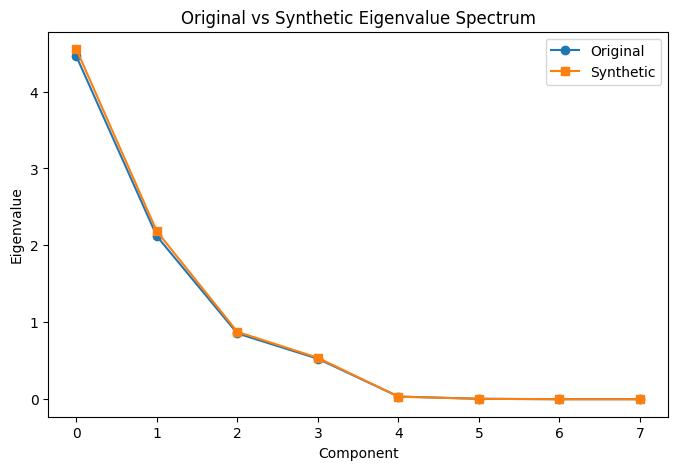

In [26]:
import matplotlib.pyplot as plt

# Compare original vs synthetic eigenvalue spectra
cov_syn = np.cov(X_syn, rowvar=False)
eigs_syn = np.sort(np.linalg.eigvalsh(cov_syn))[::-1]
eigs_orig = np.sort(np.linalg.eigvalsh(cov_original))[::-1]

plt.figure(figsize=(8,5))
plt.plot(eigs_orig, marker='o', label='Original')
plt.plot(eigs_syn, marker='s', label='Synthetic')
plt.title("Original vs Synthetic Eigenvalue Spectrum")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.legend()
plt.show()

In [27]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.5 MB/s eta 0:00:00


In [28]:
import pennylane as qml
import numpy as np

n_qubits = 8  # one per feature

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    return qml.state()

# Test with one sample
sample = X_syn[0]
state = quantum_feature_map(sample)
print("Quantum state shape:", state.shape)

Quantum state shape: (256,)


In [29]:
@qml.qnode(dev)
def kernel_circuit(x1, x2):
    # Encode x1
    for i in range(n_qubits):
        qml.RY(x1[i], wires=i)
    # Inverse encode x2
    for i in range(n_qubits - 1, -1, -1):
        qml.RY(-x2[i], wires=i)
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(x1, x2):
    probs = kernel_circuit(x1, x2)
    return probs[0]  # |<ψ(x1)|ψ(x2)>|^2

# Test kernel
k = quantum_kernel(X_syn[0], X_syn[1])
print("Kernel value between sample 0 and 1:", k)

Kernel value between sample 0 and 1: 0.10671348204636376


In [30]:
# Use small subset for speed
n_subset = 100
X_subset = X_syn[:n_subset]
y_subset = np.random.randint(0, 2, size=n_subset)  # binary labels

print("Building Gram matrix...")
G = np.zeros((n_subset, n_subset))

for i in range(n_subset):
    for j in range(n_subset):
        G[i, j] = quantum_kernel(X_subset[i], X_subset[j])
    if i % 10 == 0:
        print(f"  Row {i}/{n_subset} done")

print("Gram matrix shape:", G.shape)

Building Gram matrix...
  Row 0/100 done
  Row 10/100 done
  Row 20/100 done
  Row 30/100 done
  Row 40/100 done
  Row 50/100 done
  Row 60/100 done
  Row 70/100 done
  Row 80/100 done
  Row 90/100 done
Gram matrix shape: (100, 100)


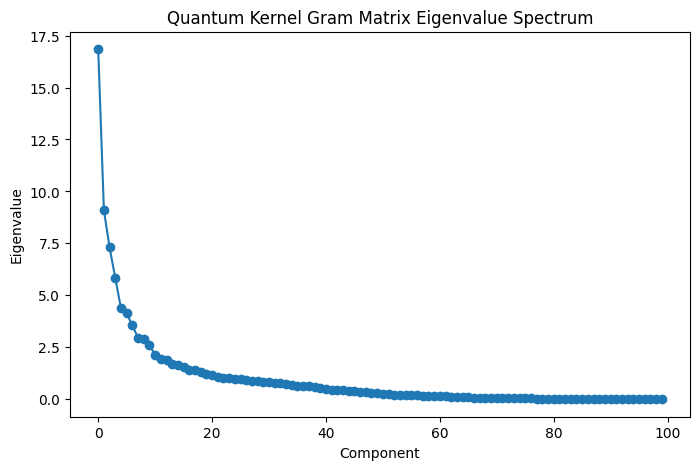

Gram Eigenvalues: [16.84227259  9.08738299  7.30465994  5.8336138   4.37041807]


In [31]:
import matplotlib.pyplot as plt

gram_eigenvalues = np.linalg.eigvalsh(G)[::-1]

plt.figure(figsize=(8,5))
plt.plot(gram_eigenvalues, marker='o')
plt.title("Quantum Kernel Gram Matrix Eigenvalue Spectrum")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()

print("Gram Eigenvalues:", gram_eigenvalues[:5])

In [32]:
def kernel_alignment(G, y):
    Y = np.outer(y, y)  # label kernel

    alignment = np.sum(G * Y) / (
        np.linalg.norm(G, 'fro') * np.linalg.norm(Y, 'fro')
    )
    return alignment

alignment_score = kernel_alignment(G, y_subset)
print("Kernel Alignment Score:", alignment_score)

Kernel Alignment Score: 0.3015803595424663


In [33]:
from pennylane.optimize import NesterovMomentumOptimizer

n_layers = 2

dev_var = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_var)
def variational_circuit(weights, x):
    # Angle encoding
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    # Variational layers
    for layer in weights:
        for i in range(n_qubits):
            qml.RY(layer[i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
    return qml.expval(qml.PauliZ(0))

def cost(weights, X, y):
    preds = np.array([variational_circuit(weights, x) for x in X])
    labels = 2 * y - 1  # convert 0/1 to -1/+1
    return np.mean((preds - labels) ** 2)

# Initialize weights
weights = np.random.uniform(
    -np.pi, np.pi,
    size=(n_layers, n_qubits)
)

# Small training subset
X_train_q = X_syn[:50]
y_train_q = y_subset[:50]

# Train
opt = NesterovMomentumOptimizer(stepsize=0.1)
epochs = 20
cost_history = []

print("Training variational quantum classifier...")
for epoch in range(epochs):
    weights, c = opt.step_and_cost(
        lambda w: cost(w, X_train_q, y_train_q),
        weights
    )
    cost_history.append(c)
    if epoch % 5 == 0:
        print(f"Epoch {epoch} — Cost: {c:.4f}")

Training variational quantum classifier...


/usr/local/lib/python3.12/dist-packages/pennylane/_grad/grad.py:337: UserWarning: Attempted to differentiate a function with no trainable parameters. If this is unintended, please add trainable parameters via the 'requires_grad' attribute or 'argnums' keyword.
  warnings.warn(


Epoch 0 — Cost: 1.3467
Epoch 5 — Cost: 1.3467
Epoch 10 — Cost: 1.3467
Epoch 15 — Cost: 1.3467


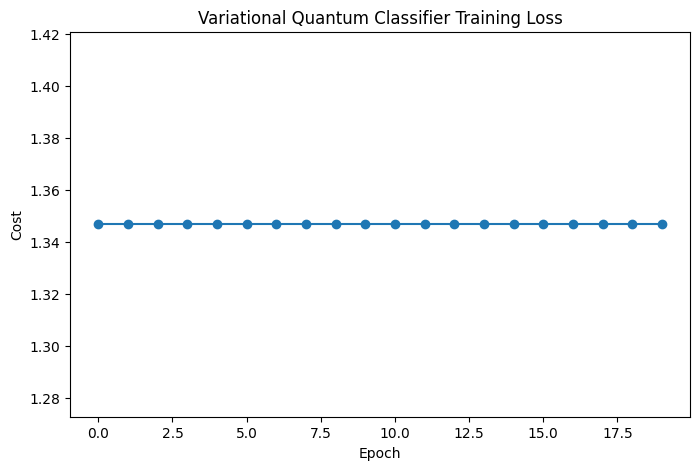

In [34]:
plt.figure(figsize=(8,5))
plt.plot(cost_history, marker='o')
plt.title("Variational Quantum Classifier Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

In [35]:
results = []

for alpha in [0.5, 1.0, 2.0]:
    # Generate synthetic data with this decay
    lam = power_law_eigenvalues(8, alpha, eigenvalues_clean.sum())
    Z = np.random.normal(0, 1, size=(50, 8))
    X_regime = Z @ np.diag(np.sqrt(lam)) @ eigenvectors.T

    y_regime = np.random.randint(0, 2, size=50)

    # Effective rank
    eff_rank = (lam.sum()**2) / (lam**2).sum()

    # Entropy
    p = lam / lam.sum()
    entropy = -np.sum(p * np.log(p + 1e-10))

    # Train classifier
    weights_r = np.random.uniform(-np.pi, np.pi, size=(n_layers, n_qubits))
    for _ in range(10):
        weights_r, c = opt.step_and_cost(
            lambda w: cost(w, X_regime, y_regime),
            weights_r
        )

    results.append({
        "alpha": alpha,
        "effective_rank": eff_rank,
        "entropy": entropy,
        "final_cost": c
    })

    print(f"Alpha={alpha} | Eff Rank={eff_rank:.2f} | Entropy={entropy:.2f} | Cost={c:.4f}")

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

Alpha=0.5 | Eff Rank=7.03 | Entropy=2.02 | Cost=1.3465
Alpha=1.0 | Eff Rank=4.84 | Entropy=1.82 | Cost=1.2697
Alpha=2.0 | Eff Rank=2.16 | Entropy=1.17 | Cost=1.3069
   alpha  effective_rank   entropy  final_cost
0    0.5        7.031076  2.017189    1.346477
1    1.0        4.836088  1.815848    1.269744
2    2.0        2.156639  1.167777    1.306902


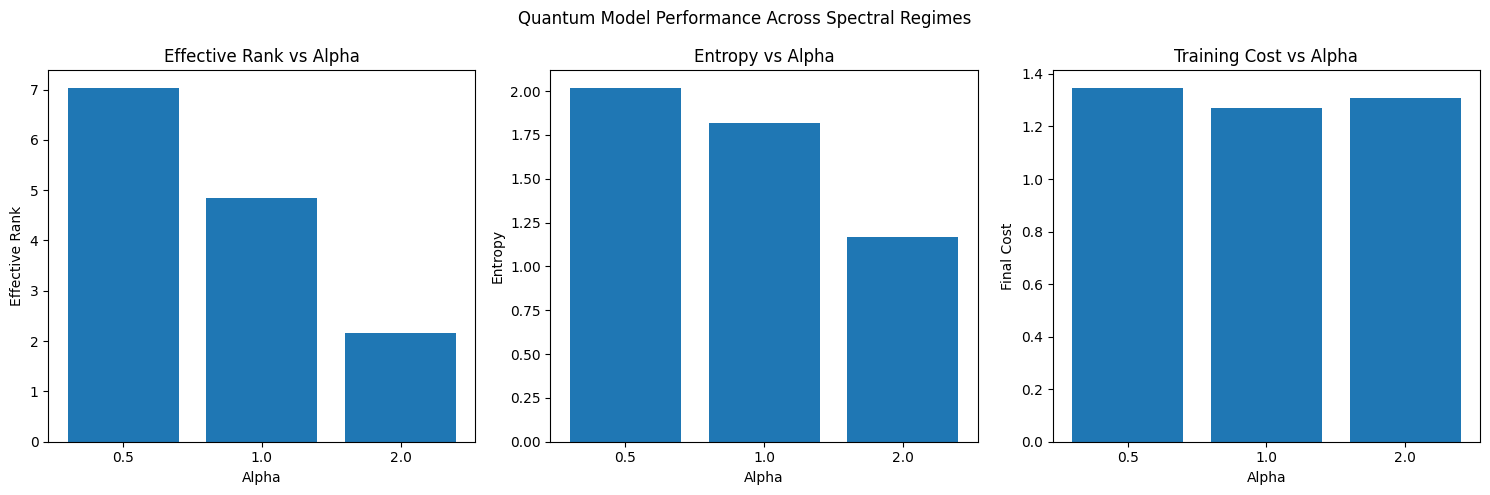

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(results_df["alpha"].astype(str), results_df["effective_rank"])
axes[0].set_title("Effective Rank vs Alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Effective Rank")

axes[1].bar(results_df["alpha"].astype(str), results_df["entropy"])
axes[1].set_title("Entropy vs Alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Entropy")

axes[2].bar(results_df["alpha"].astype(str), results_df["final_cost"])
axes[2].set_title("Training Cost vs Alpha")
axes[2].set_xlabel("Alpha")
axes[2].set_ylabel("Final Cost")

plt.suptitle("Quantum Model Performance Across Spectral Regimes")
plt.tight_layout()
plt.show()